In [1]:
import css_utility_rnakato as crb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
str1 = "up50000_down5000_stride1"
str2 = "high_exp_vs_RPKM_log1_k4"
motifdir = f"./Revision_code/motif/motif_logscale_train30000_dev6000_notomitO/{str1}/{str2}/"
motiffile = f'{motifdir}/init_df.csv'

init_df = pd.read_csv(motiffile)
init_df.head(10)

,motif,N,K,n,x,p,q
0,OOOOOAAA,6000,2981,828,556,7.154083e-28,2.325894e-27
1,EEGGG,6000,2981,2462,1539,2.488017e-62,3.220851e-61
2,EGGEE,6000,2981,536,354,9.059190e-16,1.891538e-15
3,GGGGGGG,6000,2981,2017,1254,1.445245e-43,9.616958e-43
4,EEGGEEE,6000,2981,509,338,1.356577e-15,2.824220e-15
5,OOOOOOOOEE,6000,2981,383,224,2.202039e-04,2.434553e-04
6,DDDEE,6000,2981,2155,1322,4.367571e-42,2.879362e-41
7,EEEDDD,6000,2981,2072,1296,5.625033e-48,4.500026e-47
8,EEEGE,6000,2981,505,353,5.674021e-22,1.501823e-21
9,EEEGGGGGE,6000,2981,268,175,9.740322e-08,1.341414e-07


In [4]:
init_df_filtered = init_df[-np.log10(init_df["p"]) > 20]
init_df_filtered

/Users/schona/miniconda3/envs/chrombert/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,motif,N,K,n,x,p,q
0,OOOOOAAA,6000,2981,828,556,7.154083e-28,2.325894e-27
1,EEGGG,6000,2981,2462,1539,2.488017e-62,3.220851e-61
3,GGGGGGG,6000,2981,2017,1254,1.445245e-43,9.616958e-43
6,DDDEE,6000,2981,2155,1322,4.367571e-42,2.879362e-41
7,EEEDDD,6000,2981,2072,1296,5.625033e-48,4.500026e-47
...,...,...,...,...,...,...,...
699,AAAAAAAAAAEE,6000,2981,344,282,1.887621e-37,9.333239e-37
701,EEEEDD,6000,2981,2083,1295,1.211903e-45,8.543314e-45
703,FFFFFD,6000,2981,527,381,2.041355e-28,6.728910e-28
704,CCCCCCC,6000,2981,340,282,2.415005e-39,1.375587e-38


In [5]:
init_df_filtered.to_csv("init_df_filtered.tsv", index=False)
motiffile = "init_df_filtered.tsv"

DTW computation time: 12.0521 seconds


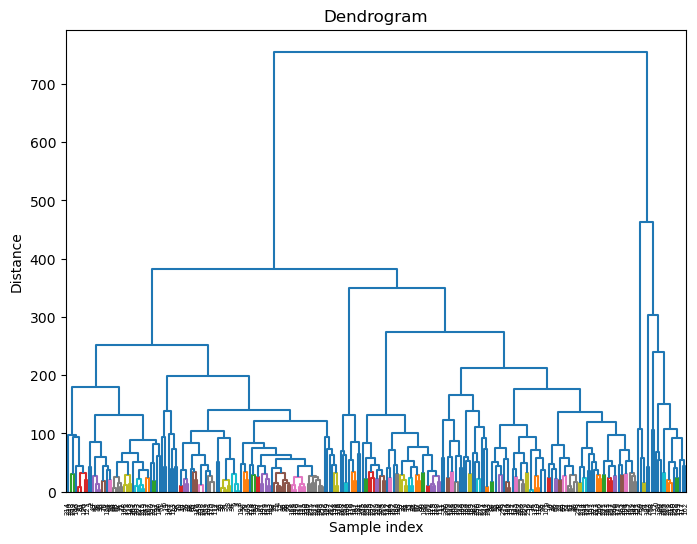

Estimated number of clusters: 141
Clustering Duration: 0:00:00.290039
Number of cluster estimated by dendrogram with designated threshold 35: [141] clusters
Min distance: 0.0
Max distance: 72.74613391789285
Median distance: 12.649110640673518


In [6]:
# dendrogram
y_pred = crb.motif_init2pred_with_dendrogram(input_path=motiffile, 
                                             categorical=False,
                                             fillna_method='ffill', 
                                             linkage_method='complete',
                                             threshold=35)

In [7]:
dtw_distance_matrix, y_pred = crb.motif_init2pred(input_path=motiffile, 
                                                  categorical=False, 
                                                  fillna_method="ffill", 
                                                  n_clusters=11, 
                                                  linkage_method="complete")
dtw_distance_matrix

DTW computation time: 10.128485918045044 seconds
Clustering Duration: 0:00:00.000924


array([[ 0.        , 29.39387691, 38.36665219, ..., 26.32489316,
        29.12043956,  0.        ],
       [29.39387691,  0.        ,  2.82842712, ...,  6.08276253,
        23.83275058, 44.63182721],
       [38.36665219,  2.82842712,  0.        , ...,  6.70820393,
        24.33105012, 43.8178046 ],
       ...,
       [26.32489316,  6.08276253,  6.70820393, ...,  0.        ,
         8.77496439, 44.59820624],
       [29.12043956, 23.83275058, 24.33105012, ...,  8.77496439,
         0.        , 55.56977596],
       [ 0.        , 44.63182721, 43.8178046 , ..., 44.59820624,
        55.56977596,  0.        ]], shape=(281, 281))

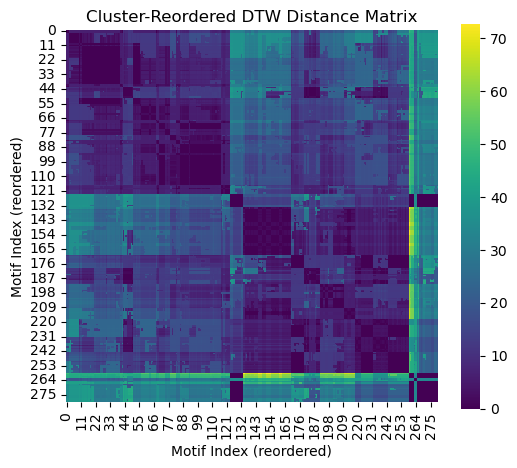

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.cluster.hierarchy import leaves_list, linkage, ClusterWarning

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ClusterWarning)
    linkage_matrix = linkage(dtw_distance_matrix, method='complete')
    ordered_indices = leaves_list(linkage_matrix)
    reordered_matrix = dtw_distance_matrix[ordered_indices][:, ordered_indices]

plt.figure(figsize=(6, 5))
sns.heatmap(reordered_matrix, cmap='viridis', square=True)
plt.title('Cluster-Reordered DTW Distance Matrix')
plt.xlabel('Motif Index (reordered)')
plt.ylabel('Motif Index (reordered)')
plt.show()

DTW computation time: 10.197303771972656 seconds
Clustering Duration: 0:00:00.000940
16


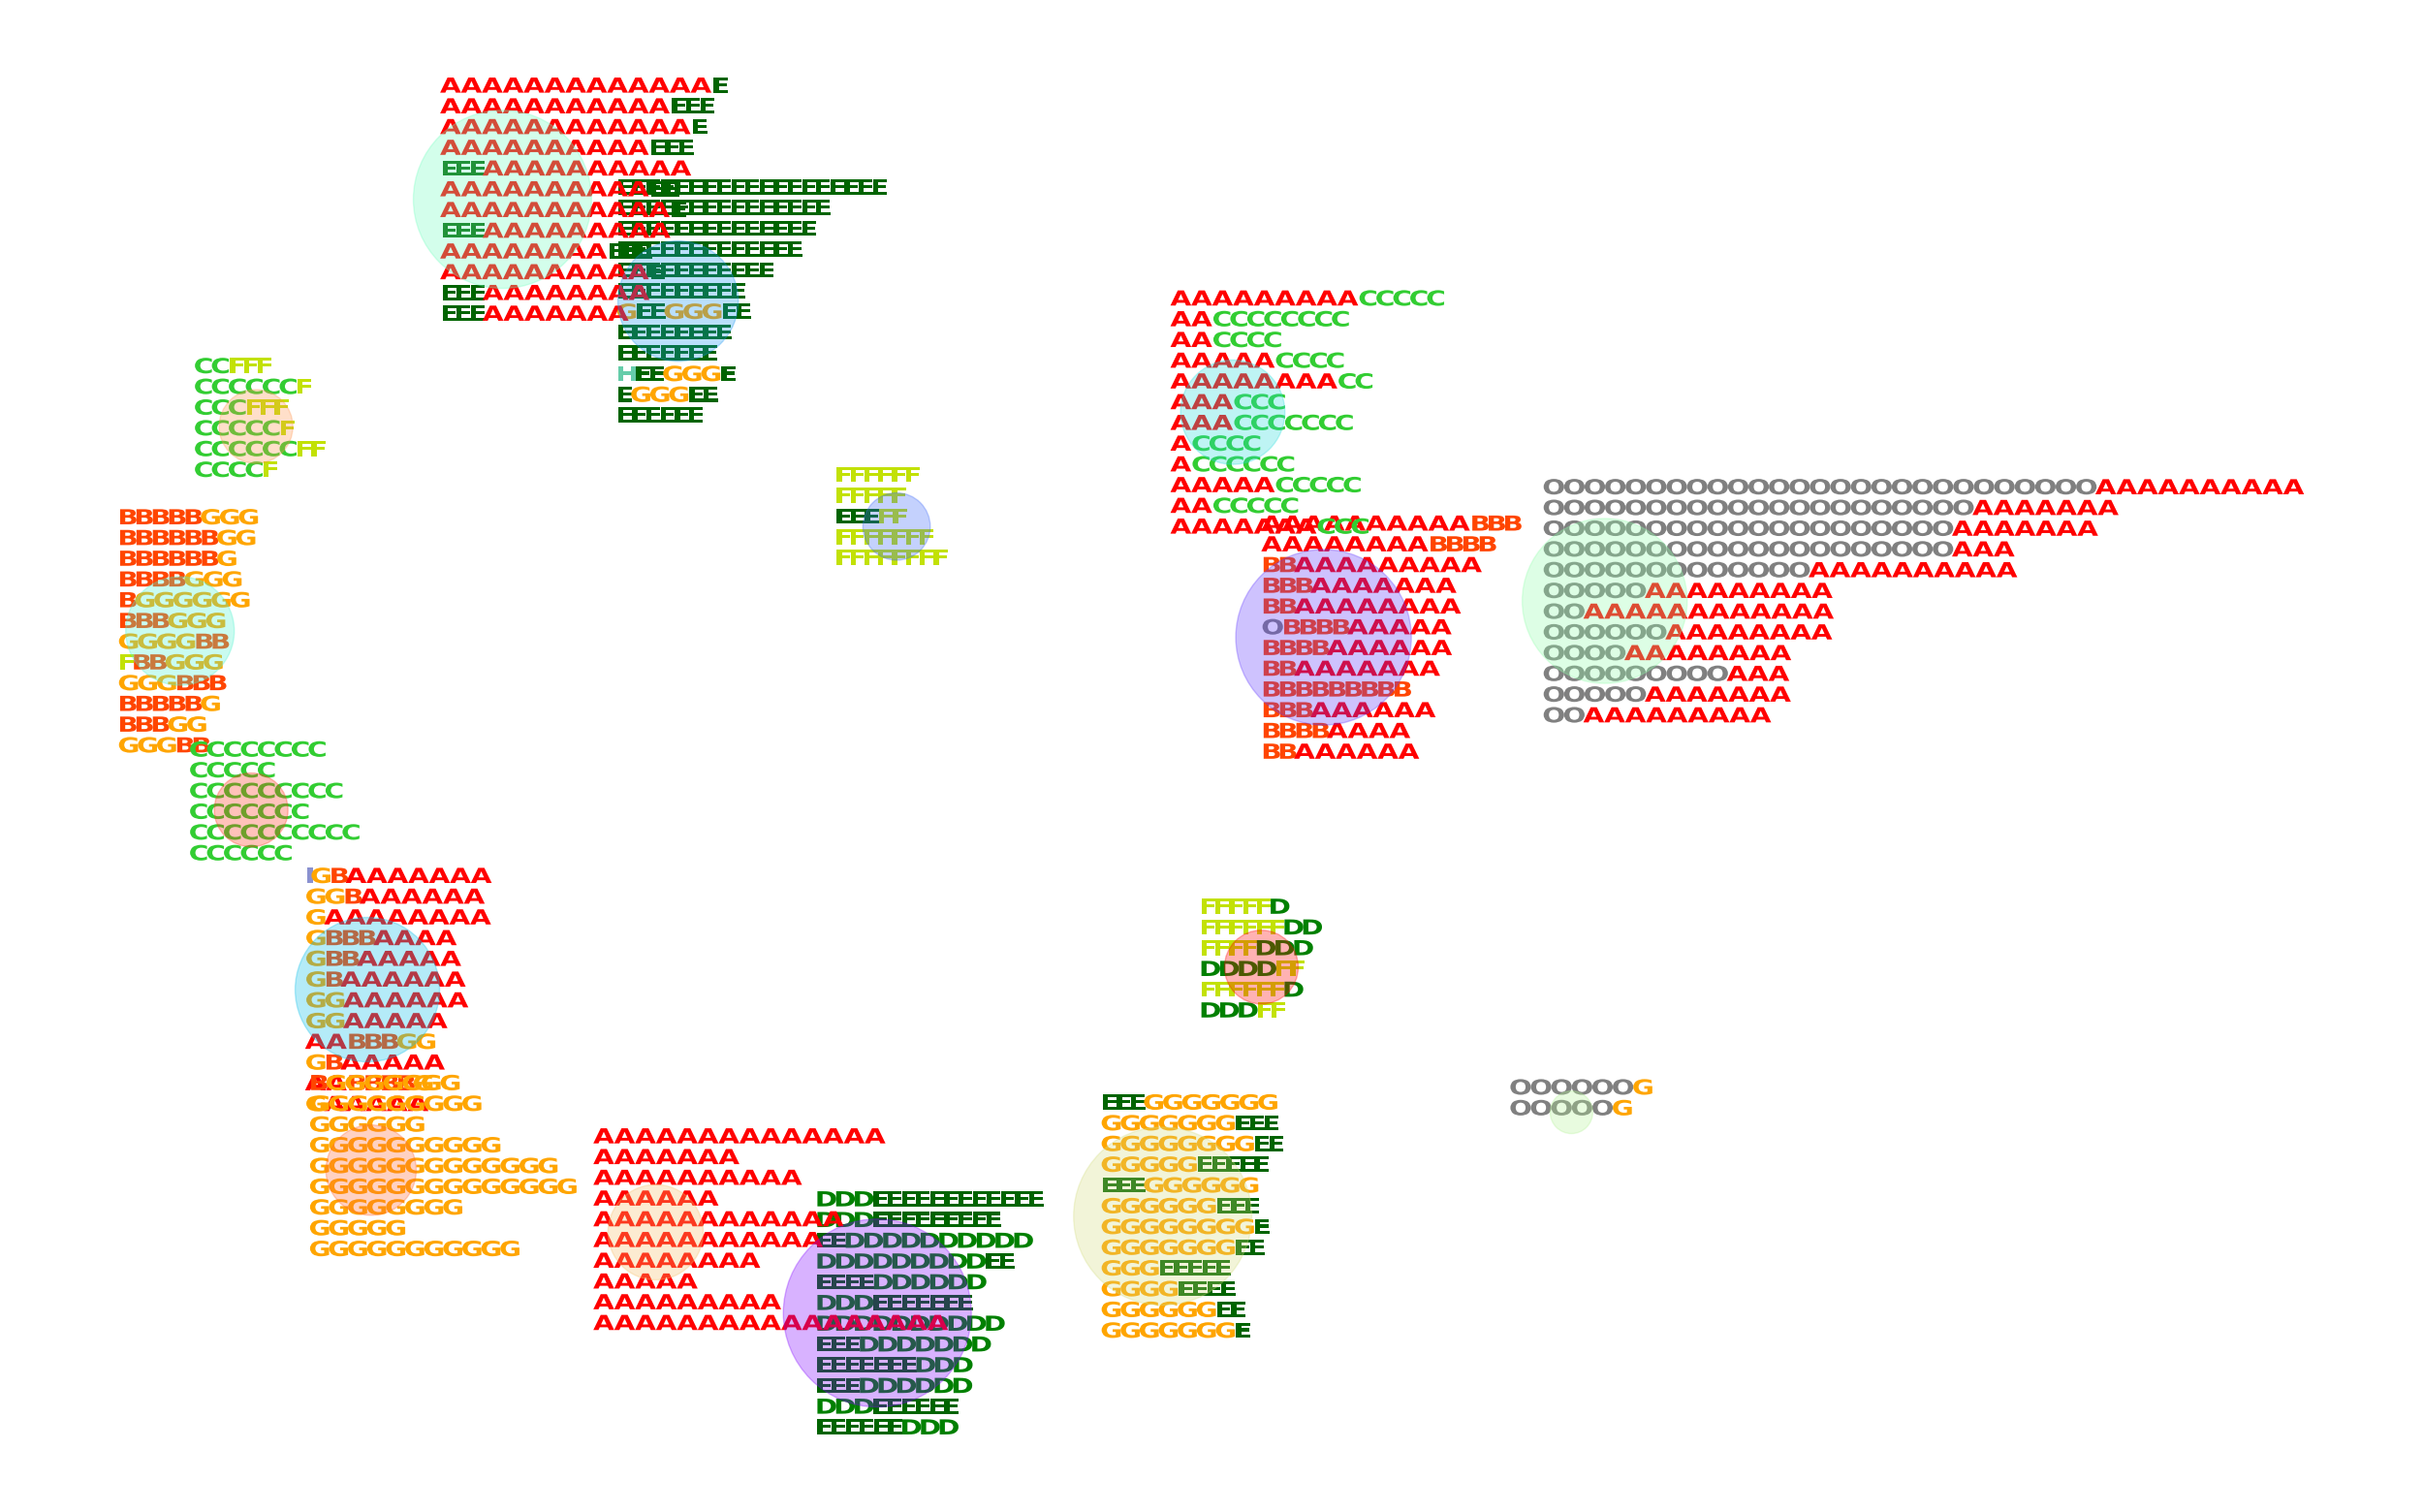

In [9]:
crb.motif_init2cluster_vis_rnakato(input_path=motiffile, 
                           categorical=False, 
                           n_clusters=16, 
                           fillna_method="ffill", 
                           linkage_method="complete", 
                           random_state=2, 
                           font_scale=0.0035,
                           font_v_scale=10, 
                           fig_w=32, 
                           fig_h=20, 
                           node_size=500, 
                           node_dist=0.05,
                           max_motifs_per_sphere=12)

DTW computation time: 10.12803602218628 seconds
Clustering Duration: 0:00:00.001067


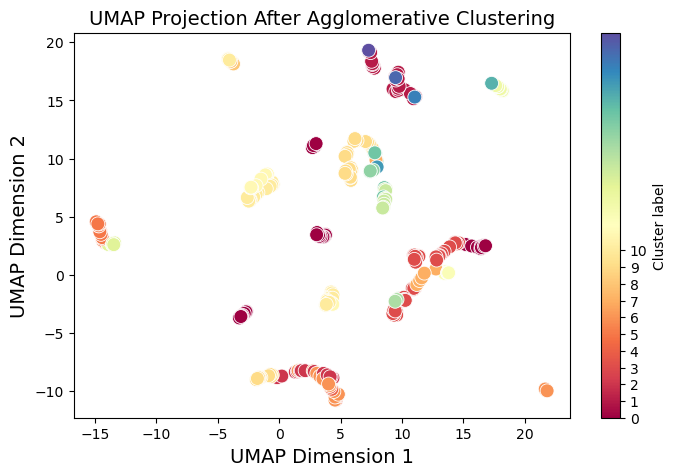

In [11]:
crb.motif_init2umap(input_path=motiffile, 
                    categorical=False,  
                    n_clusters=24, 
                    fillna_method="ffill",
                    linkage_method="complete",
                    n_neighbors=5, 
                    min_dist=0.3, 
                    random_state=2)